In [1]:
# ============================================================
# Setup
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/brain_tumor_classification')

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

from src.dataset import create_dataloaders, get_dataset_info, CLASS_NAMES
from src.transforms import get_transforms, denormalize

# Project paths
DATA_DIR = '/content/drive/MyDrive/brain_tumor_classification/data'
OUT_DIR  = '/content/drive/MyDrive/brain_tumor_classification/outputs'

# Plot styling
plt.rcParams['figure.dpi']       = 120
plt.rcParams['font.family']      = 'sans-serif'
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False

# Class colors — consistent across all plots
CLASS_COLORS = {
    'glioma':     '#4A90D9',
    'meningioma': '#E8854A',
    'notumor':    '#5DBF8A',
    'pituitary':  '#9B6DD6',
}

print("Setup complete.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.


In [2]:
# ============================================================
# Creating DataLoaders and printing summary
# ============================================================
train_loader, val_loader, test_loader, info = create_dataloaders(
    data_dir    = DATA_DIR,
    image_size  = 224,
    batch_size  = 32,
    val_split   = 0.2,
    seed        = 42,
)

get_dataset_info(info)

  Dataset Summary
  Classes      : glioma, meningioma, notumor, pituitary
  Image size   : 224x224
  Batch size   : 32

  Train set    :  4480 images  (140 batches)
  Val set      :  1120 images  (35 batches)
  Test set     :  1600 images  (50 batches)
  Total        :  7200 images

  Class → Index mapping:
    0 → glioma
    1 → meningioma
    2 → notumor
    3 → pituitary


Visualization 1 — Split sizes


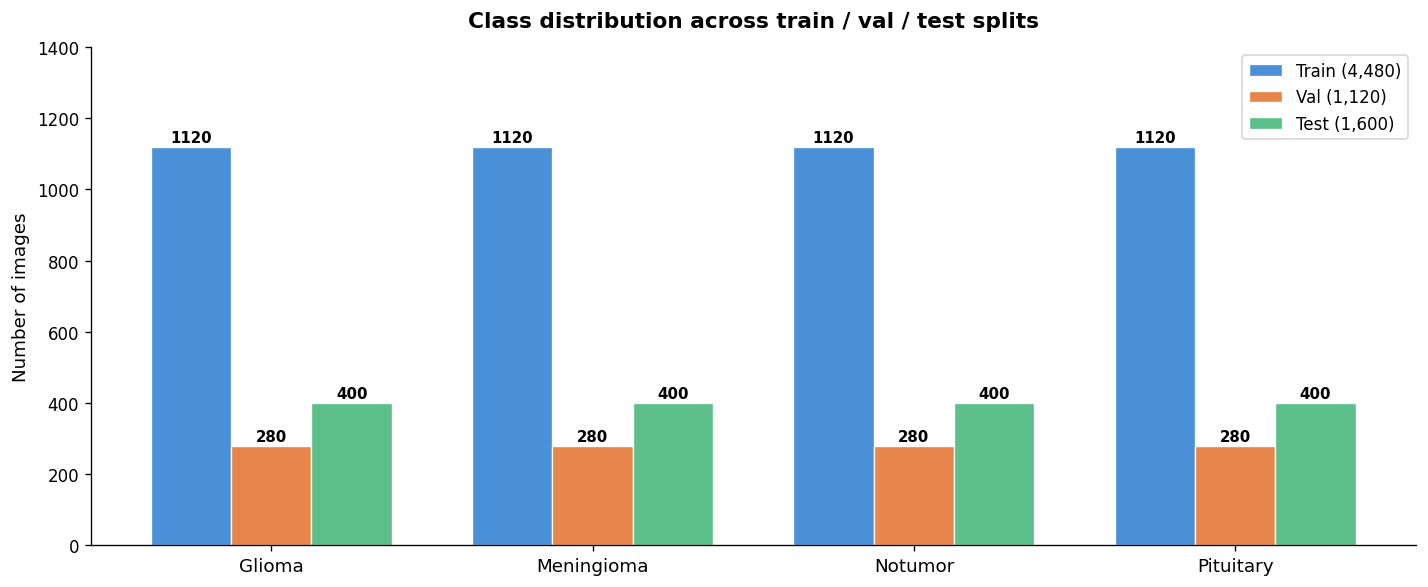

  Saved: outputs/pipeline_split_distribution.png


In [3]:
# ============================================================
# Visualization 1: Split size bar chart
#
# Shows how many images are in each split and
# how each class is distributed within each split.
# ============================================================
print("Visualization 1 — Split sizes")

from src.dataset import BrainTumorDataset

# Count per class per split by loading dataset without transforms
train_full = BrainTumorDataset(DATA_DIR + '/Training', transform=None)
test_full  = BrainTumorDataset(DATA_DIR + '/Testing',  transform=None)

# Recalculate val indices using same seed
from sklearn.model_selection import StratifiedShuffleSplit
all_labels   = train_full.get_labels()
splitter     = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(splitter.split(X=np.zeros(len(all_labels)), y=all_labels))

# Count per class in each split
def count_per_class(dataset, indices, class_names):
    counts = {c: 0 for c in class_names}
    for i in indices:
        _, label = dataset.samples[i]
        counts[class_names[label]] += 1
    return counts

train_counts = count_per_class(train_full, train_idx, CLASS_NAMES)
val_counts   = count_per_class(train_full, val_idx,   CLASS_NAMES)
test_counts  = test_full.class_counts()

# ── Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 5))

x      = np.arange(len(CLASS_NAMES))
width  = 0.25
splits = [
    ('Train (4,480)',  train_counts, '#4A90D9'),
    ('Val (1,120)',    val_counts,   '#E8854A'),
    ('Test (1,600)',   test_counts,  '#5DBF8A'),
]

for i, (label, counts, color) in enumerate(splits):
    vals = [counts[c] for c in CLASS_NAMES]
    bars = ax.bar(x + i * width, vals, width, label=label,
                  color=color, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                str(v), ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels([c.capitalize() for c in CLASS_NAMES], fontsize=11)
ax.set_ylabel('Number of images', fontsize=11)
ax.set_title('Class distribution across train / val / test splits', fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.set_ylim(0, max(train_counts.values()) * 1.25)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/pipeline_split_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("  Saved: outputs/pipeline_split_distribution.png")

Visualization 2 — Sample images from each class


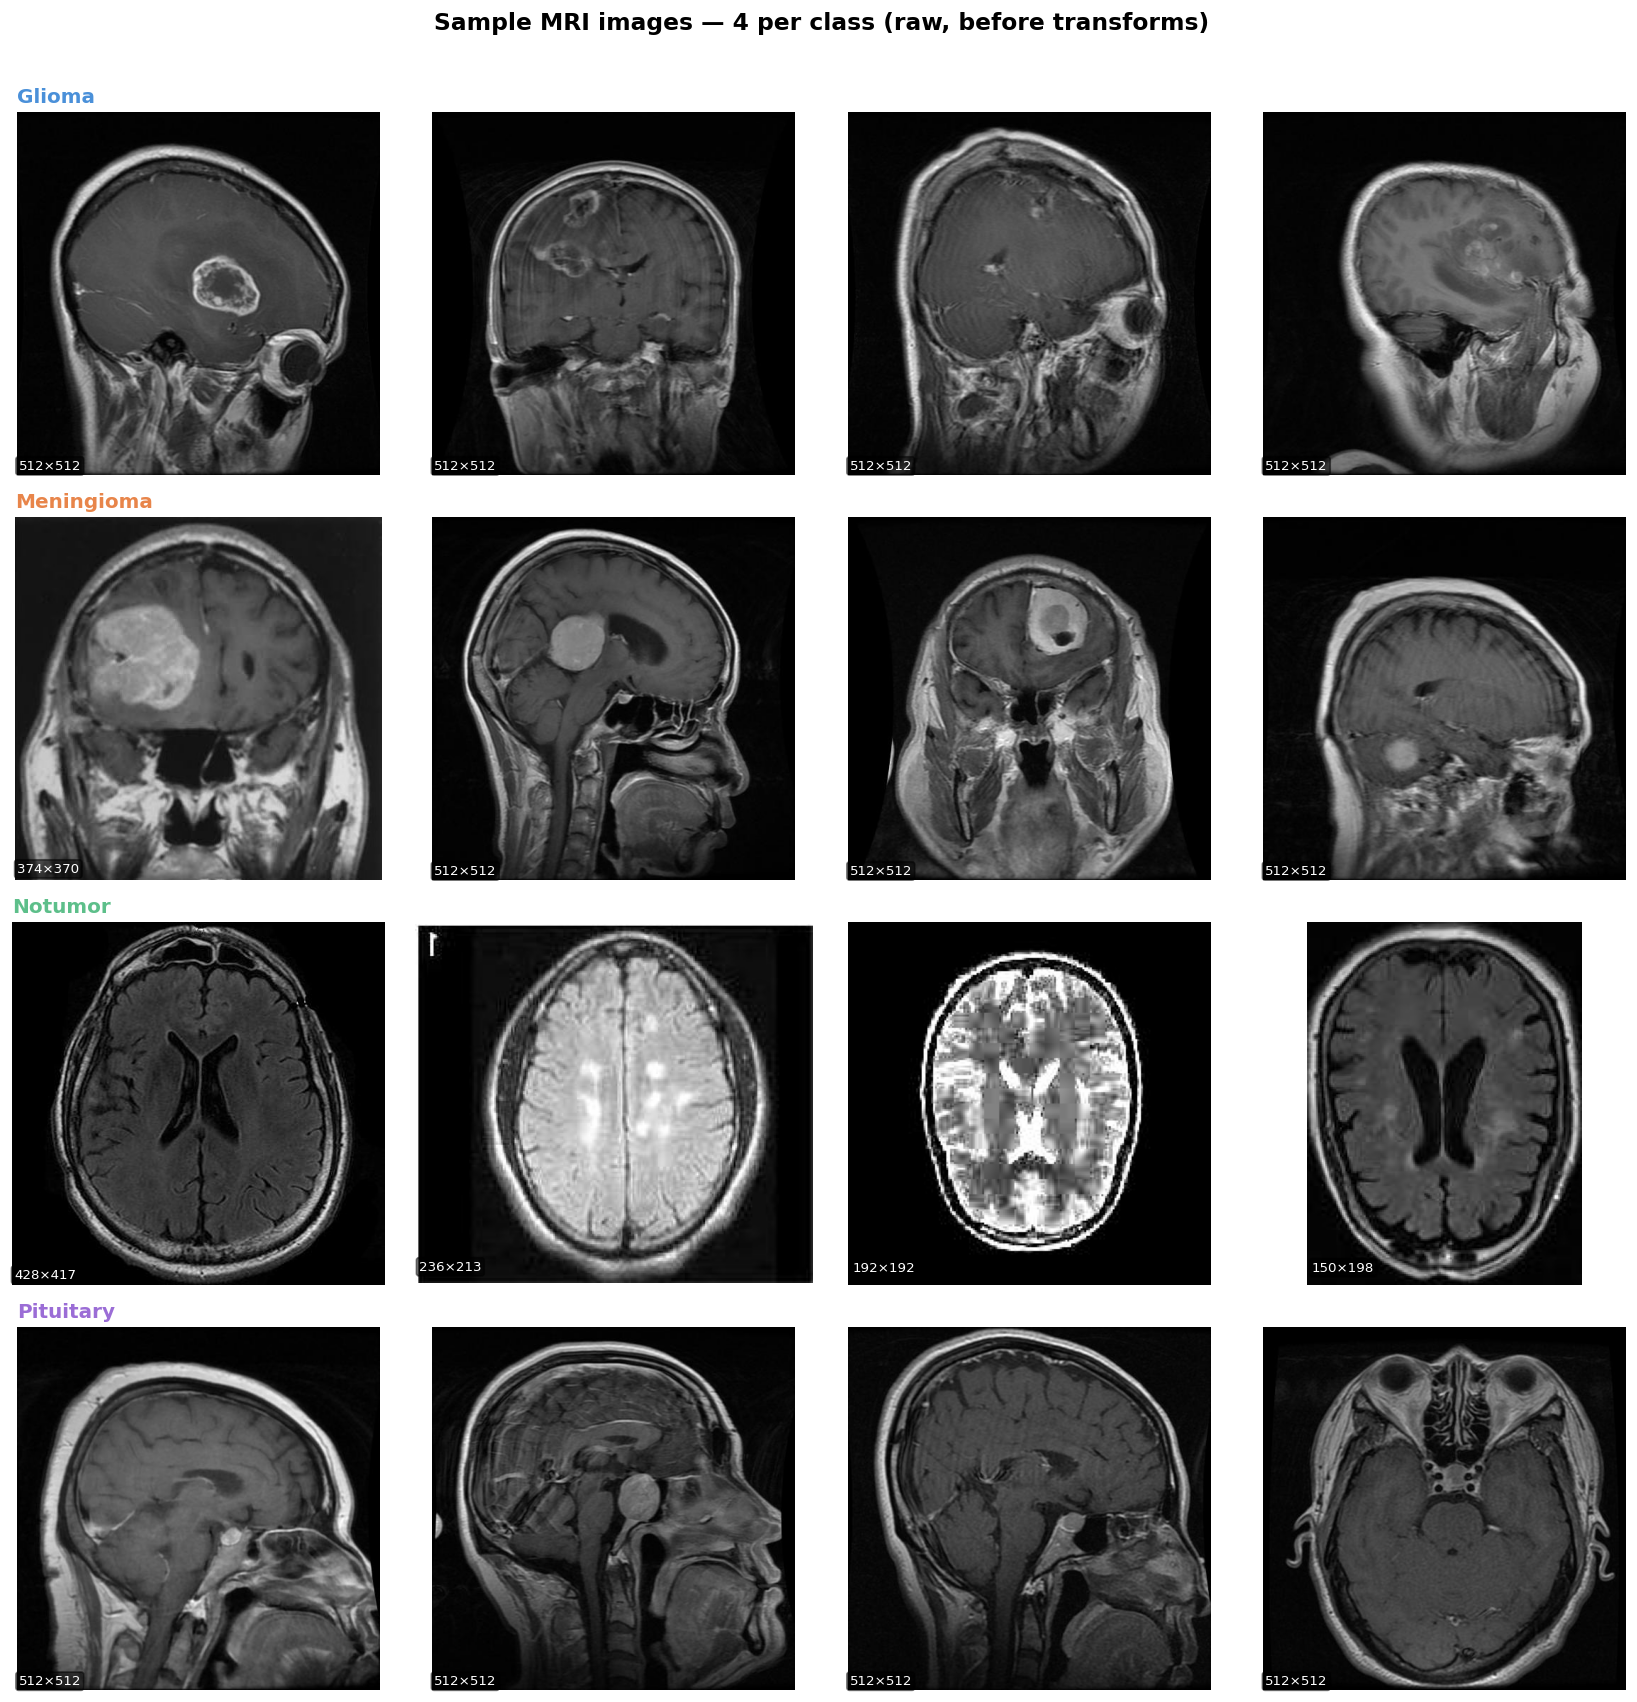

  Saved: outputs/pipeline_sample_images.png


In [5]:
# ============================================================
# Visualization 2: Sample images from each class
#
# Displays raw (unnormalized) sample images from
# the training set — 4 images per class.
# ============================================================
print("Visualization 2 — Sample images from each class")

import random
random.seed(42)

# Load raw images directly (no transform) for display
raw_dataset = BrainTumorDataset(DATA_DIR + '/Training', transform=None)

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle('Sample MRI images — 4 per class (raw, before transforms)',
             fontsize=14, fontweight='bold', y=1.01)

for row, cls in enumerate(CLASS_NAMES):
    # Get all indices for this class
    cls_indices = [i for i, (_, label) in enumerate(raw_dataset.samples)
                   if label == row]
    chosen = random.sample(cls_indices, 4)

    for col, idx in enumerate(chosen):
        img_path, label = raw_dataset.samples[idx]
        img = Image.open(img_path).convert('RGB')

        ax = axes[row][col]
        ax.imshow(img)
        ax.axis('off')

        # Class label on first column only
        if col == 0:
            ax.set_title(cls.capitalize(), fontsize=12, fontweight='bold',
                        color=CLASS_COLORS[cls], loc='left', pad=6)
        # Image size annotation
        ax.text(2, img.size[1]-8, f'{img.size[0]}×{img.size[1]}',
                fontsize=8, color='white',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.5))

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/pipeline_sample_images.png', bbox_inches='tight', dpi=300)
plt.show()
print("  Saved: outputs/pipeline_sample_images.png")

In [8]:
# ============================================================
# Visualization 3: Before vs After augmentation
#
# Takes one image and shows it 8 times through the
# training augmentation pipeline — each one looks
# slightly different. This is exactly what the model
# sees during training.
# ============================================================
print("Visualization 3 — Before vs After augmentation")

# Pick one sample image from each class
import os
from pathlib import Path

fig, axes = plt.subplots(4, 9, figsize=(20, 10))
fig.suptitle('Augmentation effect — original (left) vs 8 augmented versions (right)',
             fontsize=13, fontweight='bold', y=1.01)

train_transform = get_transforms(image_size=224, phase='train')

for row, cls in enumerate(CLASS_NAMES):
    # Pick a fixed image for this class
    cls_dir   = Path(DATA_DIR) / 'Training' / cls
    img_files = sorted([f for f in cls_dir.iterdir()
                        if f.suffix.lower() in {'.jpg','.jpeg','.png'}])
    img_path  = img_files[10]  # pick image #10
    orig_img  = np.array(Image.open(img_path).convert('RGB'))

    # Column 0: original image
    ax = axes[row][0]
    ax.imshow(orig_img)
    ax.axis('off')
    ax.set_title('Original', fontsize=9, fontweight='bold', color='gray')
    if row == 0:
        ax.set_title('Original', fontsize=9, fontweight='bold', color='gray')

    # Vertical class label
    axes[row][0].set_ylabel(cls.capitalize(), fontsize=11, fontweight='bold',
                            color=CLASS_COLORS[cls], rotation=90, labelpad=8)

    # Separator line after original
    axes[row][0].patch.set_edgecolor(CLASS_COLORS[cls])
    axes[row][0].patch.set_linewidth(2)

    # Columns 1–8: augmented versions
    for col in range(1, 9):
        augmented = train_transform(image=orig_img.copy())
        aug_img   = denormalize(augmented['image'])

        ax = axes[row][col]
        ax.imshow(aug_img)
        ax.axis('off')
        if row == 0:
            ax.set_title(f'Aug {col}', fontsize=9, color='#888')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/pipeline_augmentation.png', bbox_inches='tight', dpi=300)
plt.show()
print("  Saved: outputs/pipeline_augmentation.png")

Output hidden; open in https://colab.research.google.com to view.

Visualization 4 — Real batch from DataLoader
  Batch tensor shape : torch.Size([32, 3, 224, 224])
  Labels             : [3, 0, 0, 3, 1, 0, 1, 2, 0, 1, 3, 2, 0, 0, 3, 2, 2, 0, 2, 0, 2, 2, 2, 2, 3, 0, 1, 1, 2, 0, 2, 3]
  Label names        : ['pituitary', 'glioma', 'glioma', 'pituitary', 'meningioma', 'glioma', 'meningioma', 'notumor', 'glioma', 'meningioma', 'pituitary', 'notumor', 'glioma', 'glioma', 'pituitary', 'notumor', 'notumor', 'glioma', 'notumor', 'glioma', 'notumor', 'notumor', 'notumor', 'notumor', 'pituitary', 'glioma', 'meningioma', 'meningioma', 'notumor', 'glioma', 'notumor', 'pituitary']
  Pixel value range  : [-2.118, 2.640]
  (Negative values are normal — this is normalized data)


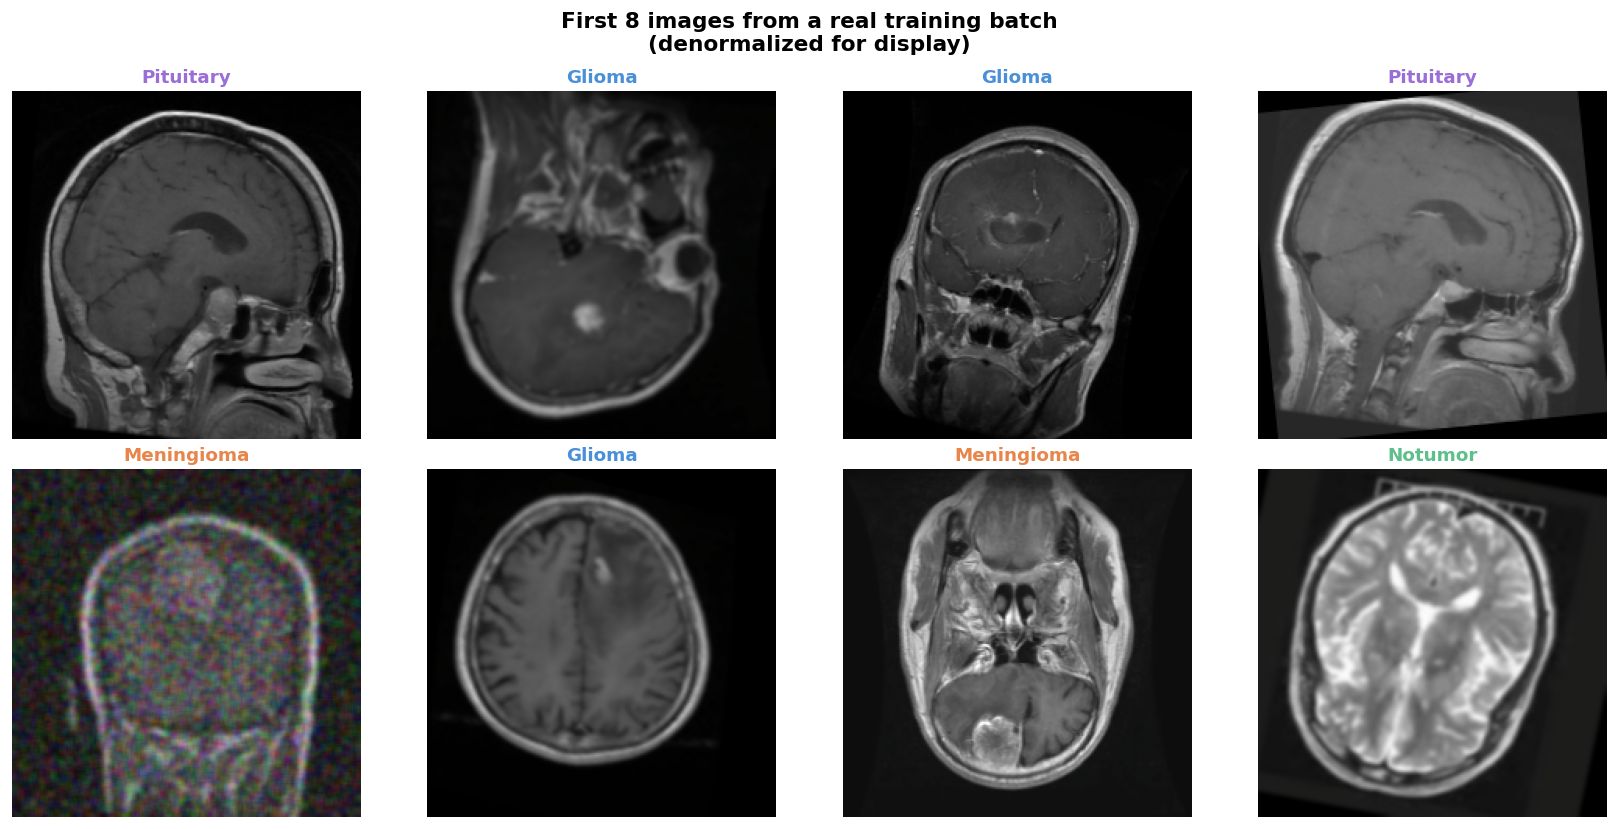

  Saved: outputs/pipeline_batch_sample.png


In [9]:
# ============================================================
# Visualization 4: Tensor inspection
#
# Loads one real batch from the DataLoader and
# shows exactly what the model receives:
# normalized tensors displayed as a grid.
# ============================================================
print("Visualization 4 — Real batch from DataLoader")

# Get one batch
images, labels = next(iter(train_loader))

print(f"  Batch tensor shape : {images.shape}")
print(f"  Labels             : {labels.tolist()}")
print(f"  Label names        : {[CLASS_NAMES[l] for l in labels.tolist()]}")
print(f"  Pixel value range  : [{images.min():.3f}, {images.max():.3f}]")
print(f"  (Negative values are normal — this is normalized data)")

# Display first 8 images from the batch
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('First 8 images from a real training batch\n(denormalized for display)',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img_display = denormalize(images[i])
    label_name  = CLASS_NAMES[labels[i].item()]
    color       = CLASS_COLORS[label_name]

    ax.imshow(img_display)
    ax.set_title(label_name.capitalize(), fontsize=11,
                fontweight='bold', color=color, pad=5)
    ax.axis('off')

    # Add a colored border matching the class
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(2.5)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/pipeline_batch_sample.png', bbox_inches='tight', dpi=300)
plt.show()
print("  Saved: outputs/pipeline_batch_sample.png")

In [12]:
# ============================================================
# Final summary
# ============================================================
print("" + "=" * 52)
print("  Phase 2 — Data Pipeline Complete")
print("=" * 52)
print(f"""
  Files created:
  ─────────────────────────────────────────────
  src/transforms.py      Preprocessing + augmentation
  src/dataset.py         Dataset, splits, DataLoaders

  Verified:
  ─────────────────────────────────────────────
  Train set     : {info['train_size']:>5} images  ({info['train_batches']} batches)
  Val set       : {info['val_size']:>5} images  ({info['val_batches']} batches)
  Test set      : {info['test_size']:>5} images  ({info['test_batches']} batches)
  Tensor shape  : [32, 3, 224, 224]
  Augmentation  : Working correctly

  Saved visualizations:
  ─────────────────────────────────────────────
  outputs/pipeline_split_distribution.png
  outputs/pipeline_sample_images.png
  outputs/pipeline_augmentation.png
  outputs/pipeline_batch_sample.png
  ─────────────────────────────────────────────
""")

  Phase 2 — Data Pipeline Complete

  Files created:
  ─────────────────────────────────────────────
  src/transforms.py      Preprocessing + augmentation
  src/dataset.py         Dataset, splits, DataLoaders

  Verified:
  ─────────────────────────────────────────────
  Train set     :  4480 images  (140 batches)
  Val set       :  1120 images  (35 batches)
  Test set      :  1600 images  (50 batches)
  Tensor shape  : [32, 3, 224, 224]
  Augmentation  : Working correctly

  Saved visualizations:
  ─────────────────────────────────────────────
  outputs/pipeline_split_distribution.png
  outputs/pipeline_sample_images.png
  outputs/pipeline_augmentation.png
  outputs/pipeline_batch_sample.png
  ─────────────────────────────────────────────

